In [50]:
# =============================================================================
# Competitive Frontier & Volatility Tercile Analysis
# =============================================================================
# Shows that model gains concentrate where volatility/competition is high.
# Uses a mean-CPC × volatility quadrant ("competitive frontier") and
# volatility terciles to segment keywords and report per-segment metrics.
# =============================================================================

import os
import json
import torch
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# ── Paths (local) ──────────────────────────────────────────────────────────
TENSOR_ROOT = "tensors"
TIME_SERIES_PATH = "../data/sem_dtw_geo_enriched_dummies.parquet"
KEYWORD_MAP_PATH = "/Users/edoardobeccari/Documents/GitHub/master_thesis/data/sebs_keyword_graph_knn/keyword_map.json"

TARGET_COL = 'cpc_week'
TEST_WEEKS_LAST = 12
VAL_RATIO = 0.25
NUM_NODES = 1811

plt.rcParams.update({
    'figure.figsize': (12, 7), 'font.size': 11,
    'axes.titlesize': 13, 'axes.labelsize': 12,
})

In [51]:
# =============================================================================
# Load data & keyword map, compute per-keyword CPC statistics
# =============================================================================

df = pd.read_parquet(TIME_SERIES_PATH)
print(f"Loaded parquet: {df.shape}")

# Parse weeks to numeric YYYYWW
if df['week'].dtype == object:
    parts = df['week'].astype(str).str.split('-', expand=True)
    df['week_num'] = pd.to_numeric(parts[1]) * 100 + pd.to_numeric(parts[0])
else:
    df['week_num'] = pd.to_numeric(df['week'])

# Load keyword map (keyword string → node index)
with open(KEYWORD_MAP_PATH, 'r') as f:
    keyword_map = json.load(f)
idx_to_keyword = {v: k for k, v in keyword_map.items()}
print(f"Keyword map: {len(keyword_map)} keywords")

# ── Per-keyword statistics on RAW CPC ──────────────────────────────────────
keyword_stats = (
    df.groupby('keyword')[TARGET_COL]
    .agg(['mean', 'std', 'median', 'count'])
    .rename(columns={'mean': 'mean_cpc', 'std': 'std_cpc',
                      'median': 'median_cpc', 'count': 'n_weeks'})
)

# Coefficient of variation = normalised volatility
keyword_stats['cv_cpc'] = keyword_stats['std_cpc'] / (keyword_stats['mean_cpc'] + 1e-8)

# Week-over-week absolute change as alternative volatility measure
wow_vol = (
    df.sort_values(['keyword', 'week_num'])
    .groupby('keyword')[TARGET_COL]
    .apply(lambda s: s.diff().abs().mean())
    .rename('wow_volatility')
)
keyword_stats = keyword_stats.join(wow_vol)

# Attach node indices
keyword_stats['node_idx'] = keyword_stats.index.map(keyword_map)
keyword_stats = keyword_stats.dropna(subset=['node_idx'])
keyword_stats['node_idx'] = keyword_stats['node_idx'].astype(int)

print(f"\nKeyword stats computed for {len(keyword_stats)} keywords")
print(keyword_stats.describe().round(4))

Loaded parquet: (218924, 404)
Keyword map: 1811 keywords

Keyword stats computed for 1811 keywords
        mean_cpc    std_cpc  median_cpc    n_weeks     cv_cpc  wow_volatility  \
count  1811.0000  1811.0000   1811.0000  1811.0000  1811.0000       1811.0000   
mean      2.7469     1.3936      2.4920   120.8857     0.5137          0.9128   
std       1.7041     1.0389      1.5140     5.5229     0.1583          0.6639   
min       0.3289     0.1687      0.2674   110.0000     0.1537          0.0418   
25%       1.4292     0.7415      1.2656   116.0000     0.4071          0.4711   
50%       2.4244     1.1593      2.2029   122.0000     0.4890          0.7503   
75%       3.5637     1.7330      3.3003   126.0000     0.5892          1.1684   
max      14.7445    11.6340      9.6036   127.0000     1.7797          5.7623   

       node_idx  
count  1811.000  
mean    905.000  
std     522.935  
min       0.000  
25%     452.500  
50%     905.000  
75%    1357.500  
max    1810.000  


In [52]:
# =============================================================================
# Define volatility terciles and competitive frontier quadrants
# =============================================================================

# --- Volatility Terciles (based on CV) ---
keyword_stats['vol_tercile'] = pd.qcut(
    keyword_stats['cv_cpc'], q=3, labels=['Low', 'Medium', 'High']
)

# --- Competitive Frontier Quadrants (mean-CPC x volatility) ---
med_mean = keyword_stats['mean_cpc'].median()
med_vol  = keyword_stats['cv_cpc'].median()

def assign_quadrant(row):
    high_cpc = row['mean_cpc'] >= med_mean
    high_vol = row['cv_cpc']   >= med_vol
    if high_cpc and high_vol:       return 'High CPC / High Vol'
    elif high_cpc and not high_vol: return 'High CPC / Low Vol'
    elif not high_cpc and high_vol: return 'Low CPC / High Vol'
    else:                           return 'Low CPC / Low Vol'

keyword_stats['quadrant'] = keyword_stats.apply(assign_quadrant, axis=1)

# Lookup dicts: node_idx -> segment
node_to_tercile  = keyword_stats.set_index('node_idx')['vol_tercile'].to_dict()
node_to_quadrant = keyword_stats.set_index('node_idx')['quadrant'].to_dict()

print("=== Volatility Tercile Distribution ===")
print(keyword_stats['vol_tercile'].value_counts().sort_index())
print(f"\n=== Competitive Frontier Quadrant Distribution ===")
print(keyword_stats['quadrant'].value_counts())
print(f"\nMedian thresholds: mean_cpc={med_mean:.4f}, cv_cpc={med_vol:.4f}")

=== Volatility Tercile Distribution ===
vol_tercile
Low       604
Medium    603
High      604
Name: count, dtype: int64

=== Competitive Frontier Quadrant Distribution ===
quadrant
Low CPC / High Vol     504
High CPC / Low Vol     504
High CPC / High Vol    402
Low CPC / Low Vol      401
Name: count, dtype: int64

Median thresholds: mean_cpc=2.4244, cv_cpc=0.4890


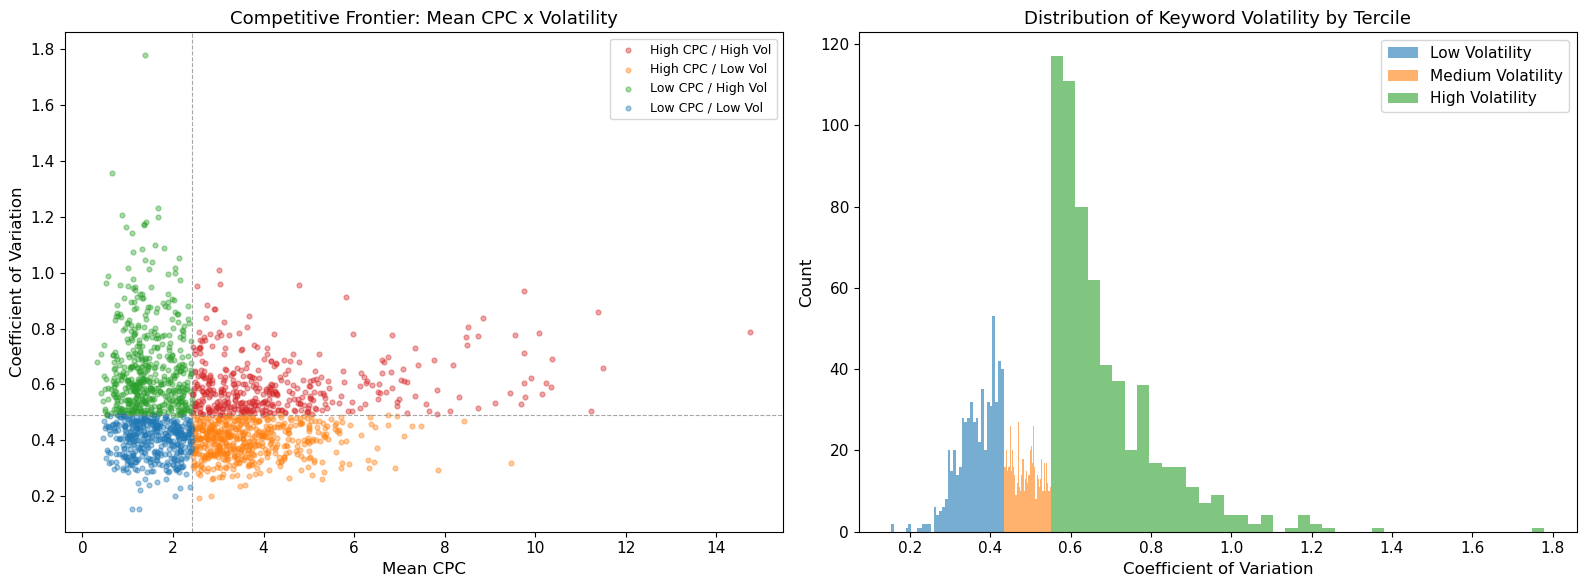

Saved: competitive_frontier_scatter.pdf


In [53]:
# =============================================================================
# Visualize the competitive frontier scatter
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Quadrant scatter ---
ax = axes[0]
colors_q = {
    'High CPC / High Vol': '#d62728',
    'High CPC / Low Vol':  '#ff7f0e',
    'Low CPC / High Vol':  '#2ca02c',
    'Low CPC / Low Vol':   '#1f77b4',
}
for quad, grp in keyword_stats.groupby('quadrant'):
    ax.scatter(grp['mean_cpc'], grp['cv_cpc'], alpha=0.4, s=12,
               label=quad, color=colors_q[quad])
ax.axvline(med_mean, color='grey', ls='--', lw=0.8, alpha=0.7)
ax.axhline(med_vol, color='grey', ls='--', lw=0.8, alpha=0.7)
ax.set_xlabel('Mean CPC')
ax.set_ylabel('Coefficient of Variation')
ax.set_title('Competitive Frontier: Mean CPC x Volatility')
ax.legend(fontsize=9, loc='upper right')

# --- Tercile histogram ---
ax2 = axes[1]
for terc in ['Low', 'Medium', 'High']:
    subset = keyword_stats[keyword_stats['vol_tercile'] == terc]
    ax2.hist(subset['cv_cpc'], bins=40, alpha=0.6, label=f'{terc} Volatility')
ax2.set_xlabel('Coefficient of Variation')
ax2.set_ylabel('Count')
ax2.set_title('Distribution of Keyword Volatility by Tercile')
ax2.legend()

plt.tight_layout()
plt.savefig('competitive_frontier_scatter.pdf', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: competitive_frontier_scatter.pdf")

In [54]:
# =============================================================================
# Universal CPC scaler + Helper functions
# =============================================================================
# KEY INSIGHT: StandardScaler fits each column independently.
# The mean & std of log1p(cpc_week) are IDENTICAL regardless of which other
# features were in the scaler during training.  So we compute them once from
# the local parquet (same CPC series, same week split) and use them for
# ALL experiments.
# =============================================================================

# --- Compute universal CPC scaler stats ---
weeks = np.array(sorted(df['week_num'].unique()))
trainval_weeks = weeks[:-TEST_WEEKS_LAST]
split_idx = int(len(trainval_weeks) * (1 - VAL_RATIO))
train_weeks = trainval_weeks[:split_idx]

cpc_train = df[df['week_num'].isin(train_weeks)][TARGET_COL].values.astype(np.float32)
cpc_train_log = np.log1p(cpc_train)
CPC_MEAN = cpc_train_log.mean()
CPC_STD  = cpc_train_log.std()

print(f"Week split: {len(train_weeks)} train, "
      f"{len(trainval_weeks) - len(train_weeks)} val, {TEST_WEEKS_LAST} test")
print(f"Universal CPC scaler: mean(log1p) = {CPC_MEAN:.6f}, std(log1p) = {CPC_STD:.6f}")


def inverse_transform_cpc(scaled_values):
    """Convert scaled log-CPC predictions/targets back to original CPC scale."""
    if isinstance(scaled_values, torch.Tensor):
        scaled_values = scaled_values.cpu().numpy()
    real = np.expm1(scaled_values.astype(np.float64) * CPC_STD + CPC_MEAN)
    return np.maximum(real, 0.0)


def compute_segment_metrics(preds, targets, node_indices):
    """
    Compute RMSE, MAE, sMAPE for a subset of nodes.
    preds, targets: [num_samples, num_nodes] in original CPC scale
    node_indices: array of node indices to evaluate
    """
    p = preds[:, node_indices]
    t = targets[:, node_indices]

    rmse = np.sqrt(np.mean((p - t) ** 2))
    mae  = np.mean(np.abs(p - t))

    # sMAPE: symmetric mean absolute percentage error
    num = np.abs(p - t)
    den = (np.abs(p) + np.abs(t)) / 2.0
    smape = 100.0 * np.mean(num / (den + 1e-8))

    # Per-node RMSE distribution
    node_rmse = np.sqrt(np.mean((p - t) ** 2, axis=0))

    return {
        'RMSE': rmse, 'MAE': mae, 'sMAPE': smape,
        'med_node_RMSE': np.median(node_rmse),
        'n_keywords': len(node_indices),
    }


def find_tensor_pairs(exp_dir, exp_name=None):
    """
    Find all (model, horizon, pred_path, target_path) in a directory.
    Handles both naming conventions:
      - exp1/exp2: {Model}_h{H}_predictions.pt
      - ablation:  {Model}_{exp_name}_h{H}_predictions.pt
    """
    all_files = set(os.listdir(exp_dir))
    pred_files = sorted(f for f in all_files if f.endswith('_predictions.pt'))
    results = []
    for pf in pred_files:
        tf = pf.replace('_predictions.pt', '_targets.pt')
        if tf not in all_files:
            continue

        # Strip suffix and parse
        base = pf.replace('_predictions.pt', '')

        # Try to extract horizon from the end: ..._h{H}
        m = re.match(r'^(.+)_h(\d+)$', base)
        if not m:
            continue
        prefix, horizon = m.group(1), int(m.group(2))

        # Remove experiment name suffix if present to get clean model name
        model_name = prefix
        if exp_name and prefix.endswith(f'_{exp_name}'):
            model_name = prefix[: -len(f'_{exp_name}')]

        results.append((model_name, horizon,
                        os.path.join(exp_dir, pf),
                        os.path.join(exp_dir, tf)))
    return results


print("Helper functions defined.")

Week split: 86 train, 29 val, 12 test
Universal CPC scaler: mean(log1p) = 1.126434, std(log1p) = 0.517456
Helper functions defined.


In [55]:
# =============================================================================
# Build node index arrays for each segment
# =============================================================================

# Tercile node indices
tercile_nodes = {}
for terc in ['Low', 'Medium', 'High']:
    nodes = keyword_stats[keyword_stats['vol_tercile'] == terc]['node_idx'].values
    tercile_nodes[terc] = np.sort(nodes)
    print(f"Tercile '{terc}': {len(nodes)} keywords")

# Quadrant node indices
quadrant_order = ['Low CPC / Low Vol', 'Low CPC / High Vol',
                  'High CPC / Low Vol', 'High CPC / High Vol']
quadrant_nodes = {}
for quad in quadrant_order:
    nodes = keyword_stats[keyword_stats['quadrant'] == quad]['node_idx'].values
    quadrant_nodes[quad] = np.sort(nodes)
    print(f"Quadrant '{quad}': {len(nodes)} keywords")

# All nodes for reference
all_nodes = np.arange(NUM_NODES)

Tercile 'Low': 604 keywords
Tercile 'Medium': 603 keywords
Tercile 'High': 604 keywords
Quadrant 'Low CPC / Low Vol': 401 keywords
Quadrant 'Low CPC / High Vol': 504 keywords
Quadrant 'High CPC / Low Vol': 504 keywords
Quadrant 'High CPC / High Vol': 402 keywords


In [56]:
# =============================================================================
# Process ALL experiment tensors -> segment-wise metrics
# =============================================================================
# Layout:
#   tensors/exp1_tensors/          -> {Model}_h{H}_*.pt
#   tensors/exp2_tensors/          -> {Model}_h{H}_*.pt
#   tensors/exp3_tensors/exp_{X}/  -> {Model}_{X}_h{H}_*.pt
#   tensors/ablation_tensors/exp_{X}/  -> {Model}_{X}_h{H}_*.pt
#   tensors/ablation2_tensors/exp_{X}/ -> {Model}_{X}_h{H}_*.pt
# =============================================================================

all_results = []

for group_name in sorted(os.listdir(TENSOR_ROOT)):
    group_path = os.path.join(TENSOR_ROOT, group_name)
    if not os.path.isdir(group_path) or group_name.startswith('.'):
        continue

    # Decide if this is a flat dir (has .pt files) or nested (has sub-experiment dirs)
    has_pt = any(f.endswith('.pt') for f in os.listdir(group_path))

    if has_pt:
        # Flat experiment: e.g. exp1_tensors/
        sub_experiments = {group_name: group_path}
    else:
        # Nested: e.g. ablation_tensors/exp_core_only/ ...
        sub_experiments = {}
        for sub in sorted(os.listdir(group_path)):
            sub_path = os.path.join(group_path, sub)
            if os.path.isdir(sub_path) and not sub.startswith('.'):
                sub_experiments[sub] = sub_path

    for exp_name, exp_dir in sub_experiments.items():
        # Derive clean experiment label (strip 'exp_' prefix if present)
        exp_label = exp_name.replace('exp_', '') if exp_name.startswith('exp_') else exp_name

        pairs = find_tensor_pairs(exp_dir, exp_name=exp_label)
        if not pairs:
            continue

        print(f"[{group_name}/{exp_name}] {len(pairs)} tensor pairs")

        for model_name, horizon, pred_path, tgt_path in pairs:
            try:
                preds_t = torch.load(pred_path, map_location='cpu', weights_only=True)
                tgts_t  = torch.load(tgt_path,  map_location='cpu', weights_only=True)

                # Inverse transform: scaled log-CPC -> original CPC
                real_preds   = inverse_transform_cpc(preds_t)
                real_targets = inverse_transform_cpc(tgts_t)

                # Reshape to [num_samples, NUM_NODES]
                real_preds   = real_preds.reshape(-1, NUM_NODES)
                real_targets = real_targets.reshape(-1, NUM_NODES)

                row_base = {
                    'exp_group': group_name,
                    'experiment': exp_label,
                    'model': model_name,
                    'horizon': horizon,
                }

                # Overall
                m = compute_segment_metrics(real_preds, real_targets, all_nodes)
                all_results.append({**row_base, 'seg_type': 'overall', 'segment': 'All', **m})

                # Tercile
                for t_name, t_idx in tercile_nodes.items():
                    m = compute_segment_metrics(real_preds, real_targets, t_idx)
                    all_results.append({**row_base, 'seg_type': 'tercile', 'segment': t_name, **m})

                # Quadrant
                for q_name, q_idx in quadrant_nodes.items():
                    m = compute_segment_metrics(real_preds, real_targets, q_idx)
                    all_results.append({**row_base, 'seg_type': 'quadrant', 'segment': q_name, **m})

            except Exception as e:
                print(f"  ERROR {model_name} h{horizon}: {e}")

df_results = pd.DataFrame(all_results)
df_results.to_csv('competitive_frontier_results.csv', index=False)
print(f"\nTotal rows: {len(df_results)}")
print(f"Exp groups: {df_results['exp_group'].unique().tolist()}")
print(f"Models: {sorted(df_results['model'].unique())}")
print("Saved: competitive_frontier_results.csv")

[ablation2_tensors/exp_core_geo_search] 12 tensor pairs
[ablation2_tensors/exp_core_geo_sem_pc] 12 tensor pairs
[ablation_tensors/exp_all_features] 12 tensor pairs
[ablation_tensors/exp_core_dom] 12 tensor pairs
[ablation_tensors/exp_core_dtw] 10 tensor pairs
[ablation_tensors/exp_core_geo] 12 tensor pairs
[ablation_tensors/exp_core_lags] 12 tensor pairs
[ablation_tensors/exp_core_only] 9 tensor pairs
[ablation_tensors/exp_core_search] 10 tensor pairs
[ablation_tensors/exp_core_sem_pc] 10 tensor pairs
[ablation_tensors/exp_core_sim25] 12 tensor pairs
[exp1_tensors/exp1_tensors] 22 tensor pairs
[exp2_tensors/exp2_tensors] 24 tensor pairs
[exp3_tensors/exp_core_city] 10 tensor pairs
[exp3_tensors/exp_core_continent] 12 tensor pairs
[exp3_tensors/exp_core_continent_search] 12 tensor pairs
[exp3_tensors/exp_core_continent_sempc] 11 tensor pairs
[exp3_tensors/exp_core_country] 10 tensor pairs
[exp3_tensors/exp_core_country_search] 11 tensor pairs

Total rows: 1880
Exp groups: ['ablation2_te

In [62]:
# =============================================================================
# TABLE 1: Tercile breakdown for MAIN experiment (exp1)
# =============================================================================

# Use exp1 as primary; fall back to exp2 if needed
exp1_mask = df_results['exp_group'] == 'exp1_tensors'
if exp1_mask.sum() == 0:
    exp1_mask = df_results['exp_group'] == 'exp2_tensors'
main_df = df_results[exp1_mask].copy()

terc_df = main_df[main_df['seg_type'] == 'tercile']
overall_df = main_df[main_df['seg_type'] == 'overall']

print("=" * 70)
print("TABLE 1: Model Performance by Volatility Tercile")
print("=" * 70)

for metric in ['sMAPE', 'RMSE', 'MAE']:
    print(f"\n{'-' * 70}")
    print(f"  Metric: {metric}")
    print(f"{'-' * 70}")
    for h in sorted(terc_df['horizon'].unique()):
        print(f"\n  Horizon h={h}")
        pivot = terc_df[terc_df['horizon'] == h].pivot_table(
            index='model', columns='segment', values=metric, aggfunc='mean'
        )
        cols = [c for c in ['Low', 'Medium', 'High'] if c in pivot.columns]
        pivot = pivot[cols]

        ov = overall_df[overall_df['horizon'] == h].set_index('model')[metric]
        pivot['Overall'] = ov

        if 'High' in pivot.columns and 'Low' in pivot.columns:
            pivot['High/Low'] = (pivot['High'] / pivot['Low']).round(2)

        print(pivot.round(4).to_string())

TABLE 1: Model Performance by Volatility Tercile

----------------------------------------------------------------------
  Metric: sMAPE
----------------------------------------------------------------------

  Horizon h=1
segment           Low   Medium     High  Overall  High/Low
model                                                     
A3TGCN        32.1291  36.6452  46.7162  38.4979      1.45
AGCRN         20.0595  27.6946  37.5131  28.4228      1.87
DCRNN         18.4642  26.1474  35.5421  26.7182      1.92
GConvLSTM     19.3132  26.7007  36.7388  27.5847      1.90
GraphWaveNet  18.9773  26.8004  36.5951  27.4580      1.93
STConv        22.4949  29.2770  39.2128  30.3288      1.74
STGCN         19.8332  27.5075  37.5187  28.2869      1.89

  Horizon h=6
segment           Low   Medium     High  Overall  High/Low
model                                                     
A3TGCN        38.8918  44.4376  55.1655  46.1659      1.42
AGCRN         22.8018  30.0125  42.3904  31.7358      

In [63]:
# =============================================================================
# TABLE 2: Quadrant breakdown for MAIN experiment
# =============================================================================

quad_df = main_df[main_df['seg_type'] == 'quadrant']

print("=" * 70)
print("TABLE 2: Model Performance by Competitive Frontier Quadrant")
print("=" * 70)

for metric in ['sMAPE', 'RMSE', 'MAE']:
    print(f"\n{'-' * 70}")
    print(f"  Metric: {metric}")
    print(f"{'-' * 70}")
    for h in sorted(quad_df['horizon'].unique()):
        print(f"\n  Horizon h={h}")
        pivot = quad_df[quad_df['horizon'] == h].pivot_table(
            index='model', columns='segment', values=metric, aggfunc='mean'
        )
        cols = [c for c in quadrant_order if c in pivot.columns]
        pivot = pivot[cols]

        if 'High CPC / High Vol' in pivot.columns and 'Low CPC / Low Vol' in pivot.columns:
            pivot['HiHi/LoLo'] = (
                pivot['High CPC / High Vol'] / pivot['Low CPC / Low Vol']
            ).round(2)

        print(pivot.round(4).to_string())

TABLE 2: Model Performance by Competitive Frontier Quadrant

----------------------------------------------------------------------
  Metric: sMAPE
----------------------------------------------------------------------

  Horizon h=1
segment       Low CPC / Low Vol  Low CPC / High Vol  High CPC / Low Vol  High CPC / High Vol  HiHi/LoLo
model                                                                                                  
A3TGCN                  33.6762             44.7646             32.4588              43.0222       1.28
AGCRN                   23.5478             34.6079             20.6414              35.2870       1.50
DCRNN                   20.1127             32.2315             20.5339              34.1486       1.70
GConvLSTM               21.8961             33.5519             20.5044              34.6548       1.58
GraphWaveNet            20.8973             33.1543             21.0506              34.8937       1.67
STConv                  24.4659       

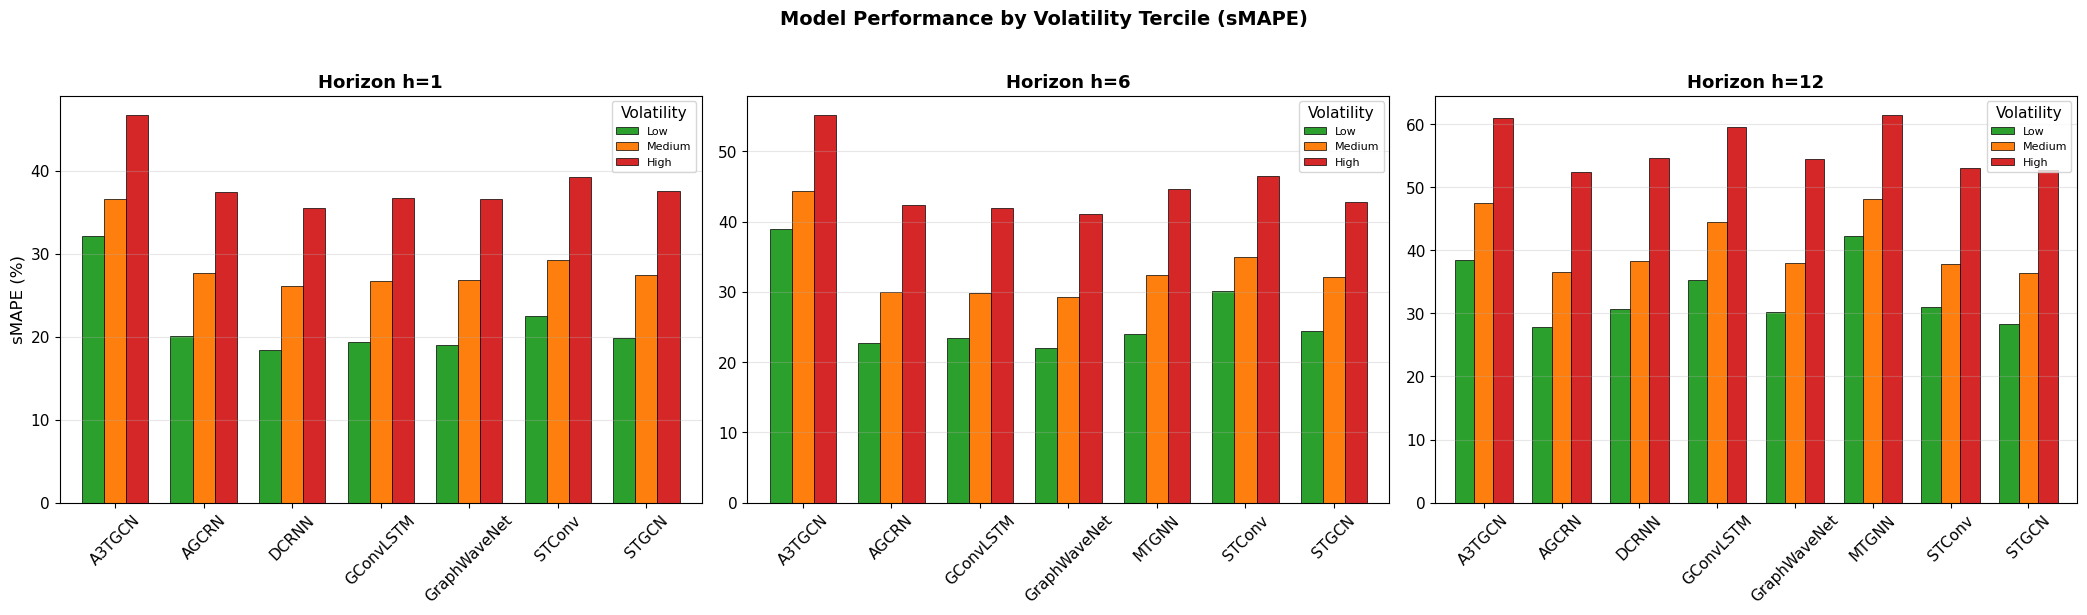

Saved: tercile_performance_bars.pdf


In [61]:
# =============================================================================
# VIZ 1: Grouped bar charts by tercile (sMAPE per model, per horizon)
# =============================================================================

horizons = sorted(main_df['horizon'].unique())
models = sorted(main_df['model'].unique())
terc_colors = {'Low': '#2ca02c', 'Medium': '#ff7f0e', 'High': '#d62728'}

fig, axes = plt.subplots(1, len(horizons), figsize=(7 * len(horizons), 6), sharey=False)
if len(horizons) == 1:
    axes = [axes]

for i, h in enumerate(horizons):
    ax = axes[i]
    subset = terc_df[terc_df['horizon'] == h]
    pivot = subset.pivot_table(index='model', columns='segment',
                               values='sMAPE', aggfunc='mean')
    cols = [c for c in ['Low', 'Medium', 'High'] if c in pivot.columns]
    pivot = pivot[cols]
    pivot.plot(kind='bar', ax=ax, color=[terc_colors[c] for c in cols],
               edgecolor='black', linewidth=0.5, width=0.75)
    ax.set_title(f'Horizon h={h}', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('sMAPE (%)' if i == 0 else '')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Volatility', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Model Performance by Volatility Tercile (sMAPE)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('tercile_performance_bars.pdf', bbox_inches='tight', dpi=150)

plt.show()
print("Saved: tercile_performance_bars.pdf")

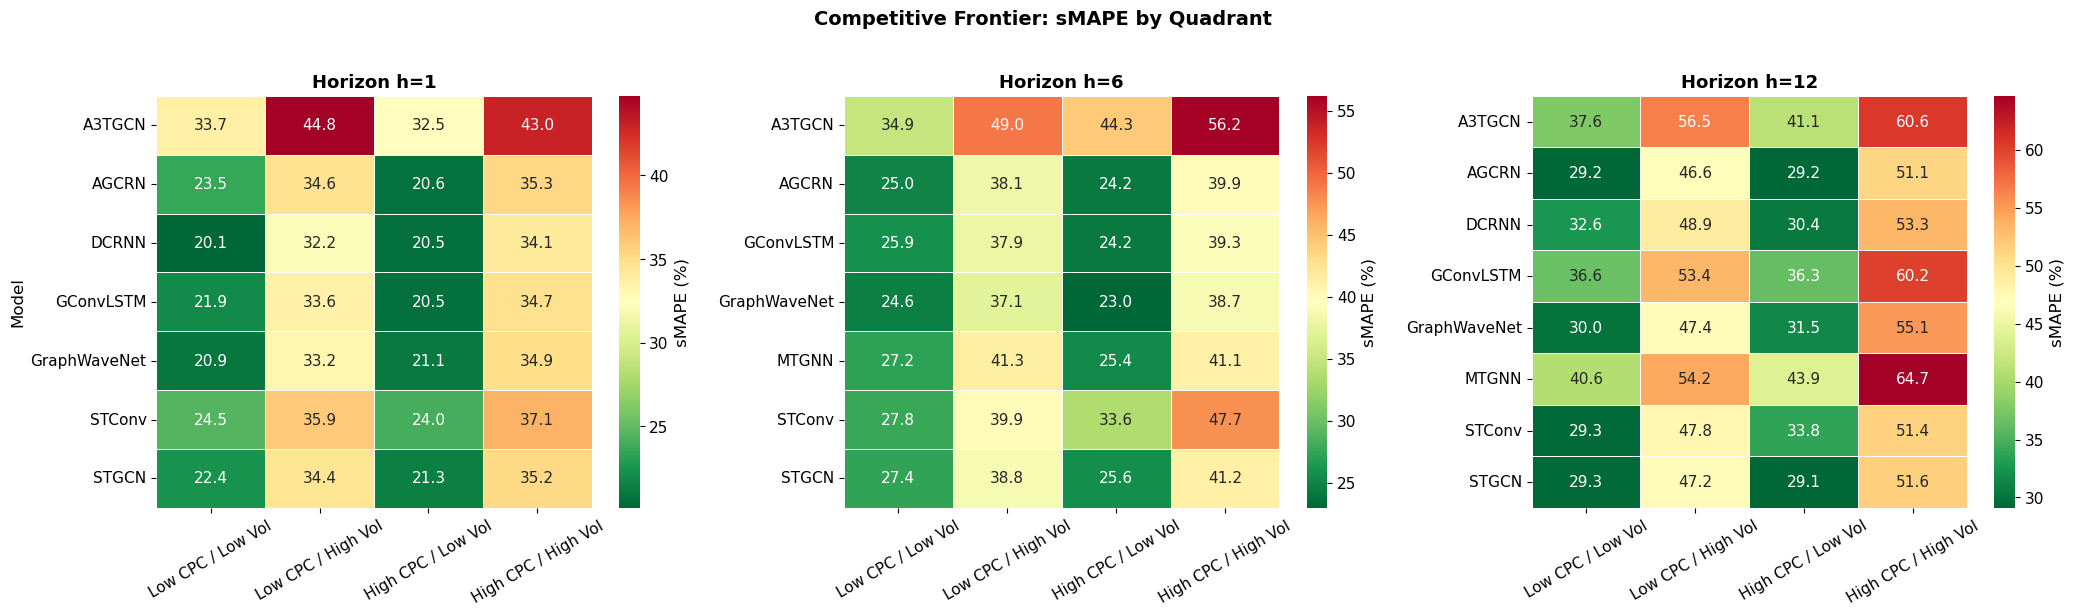

Saved: quadrant_heatmaps.pdf


In [ ]:
# =============================================================================
# VIZ 2: Quadrant heatmaps (sMAPE per model, per horizon)
# =============================================================================

fig, axes = plt.subplots(1, len(horizons), figsize=(7 * len(horizons), 6))
if len(horizons) == 1:
    axes = [axes]

quad_plot_df = main_df[main_df['seg_type'] == 'quadrant']
for i, h in enumerate(horizons):
    ax = axes[i]
    subset = quad_plot_df[quad_plot_df['horizon'] == h]
    pivot = subset.pivot_table(index='model', columns='segment',
                               values='sMAPE', aggfunc='mean')
    cols = [c for c in quadrant_order if c in pivot.columns]
    pivot = pivot[cols]
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=ax,
                linewidths=0.5, cbar_kws={'label': 'sMAPE (%)'})
    ax.set_title(f'Horizon h={h}', fontweight='bold')
    ax.set_ylabel('' if i > 0 else 'Model')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('Competitive Frontier: sMAPE by Quadrant',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('quadrant_heatmaps.pdf', bbox_inches='tight', dpi=150)

plt.show()print("Saved: quadrant_heatmaps.pdf")

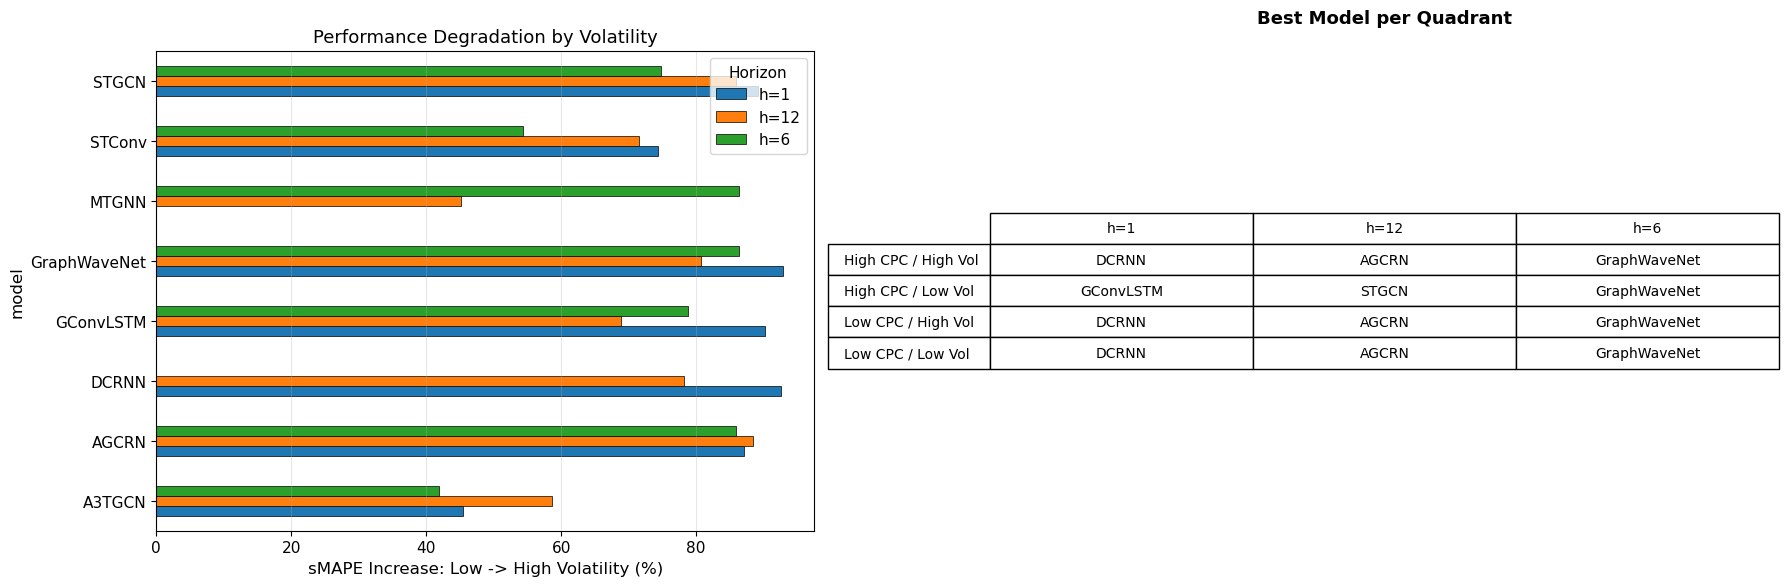

Saved: performance_degradation.pdf


In [ ]:
# =============================================================================
# VIZ 3: Performance degradation — how much worse in High vs Low volatility
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Left: sMAPE increase from Low to High tercile ---
ax = axes[0]
degradation_rows = []
for h in horizons:
    for model in models:
        sub = terc_df[(terc_df['horizon'] == h) & (terc_df['model'] == model)]
        low_v  = sub.loc[sub['segment'] == 'Low', 'sMAPE'].values
        high_v = sub.loc[sub['segment'] == 'High', 'sMAPE'].values
        if len(low_v) and len(high_v):
            pct = 100.0 * (high_v[0] - low_v[0]) / (low_v[0] + 1e-8)
            degradation_rows.append({'model': model, 'horizon': f'h={h}', 'pct': pct})

deg_df = pd.DataFrame(degradation_rows)
if len(deg_df):
    pivot_deg = deg_df.pivot_table(index='model', columns='horizon', values='pct')
    pivot_deg.plot(kind='barh', ax=ax, edgecolor='black', linewidth=0.5)
    ax.set_xlabel('sMAPE Increase: Low -> High Volatility (%)')
    ax.set_title('Performance Degradation by Volatility')
    ax.legend(title='Horizon')
    ax.grid(axis='x', alpha=0.3)

# --- Right: Best model per quadrant table ---
ax2 = axes[1]
best_rows = []
quad_plot = main_df[main_df['seg_type'] == 'quadrant']
for h in horizons:
    for quad in quadrant_order:
        sub = quad_plot[(quad_plot['horizon'] == h) & (quad_plot['segment'] == quad)]
        if len(sub):
            best = sub.loc[sub['sMAPE'].idxmin()]
            best_rows.append({'horizon': f'h={h}', 'quadrant': quad,
                              'best_model': best['model'], 'sMAPE': f"{best['sMAPE']:.1f}"})

best_df = pd.DataFrame(best_rows)
if len(best_df):
    pivot_best = best_df.pivot_table(index='quadrant', columns='horizon',
                                      values='best_model', aggfunc='first')
    ax2.axis('off')
    table = ax2.table(cellText=pivot_best.values,
                      rowLabels=pivot_best.index, colLabels=pivot_best.columns,
                      cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.8)
    ax2.set_title('Best Model per Quadrant', fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('performance_degradation.pdf', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: performance_degradation.pdf")

In [ ]:
# =============================================================================
# TABLE 3: Ablation — do added features help more for high-vol keywords?
# =============================================================================
# For each ablation experiment, show sMAPE by tercile.  If a feature group
# disproportionately improves the High tercile, it confirms the "competitive
# frontier" hypothesis.
# =============================================================================

# Gather ablation + exp3 results (all non-main experiments)
abl_mask = ~df_results['exp_group'].isin(['exp1_tensors', 'exp2_tensors'])
abl_df = df_results[abl_mask & (df_results['seg_type'] == 'tercile')].copy()

if len(abl_df) == 0:
    print("No ablation experiments found.")
else:
    # For each model, report the tercile sMAPE across experiments
    for model in sorted(abl_df['model'].unique()):
        model_sub = abl_df[abl_df['model'] == model]
        if len(model_sub) == 0:
            continue

        print(f"\n{'='*70}")
        print(f"  Model: {model}")
        print(f"{'='*70}")

        for h in sorted(model_sub['horizon'].unique()):
            h_sub = model_sub[model_sub['horizon'] == h]
            pivot = h_sub.pivot_table(
                index='experiment', columns='segment',
                values='sMAPE', aggfunc='mean'
            )
            if not {'Low', 'Medium', 'High'}.issubset(pivot.columns):
                continue
            pivot = pivot[['Low', 'Medium', 'High']]
            pivot['High-Low Gap'] = pivot['High'] - pivot['Low']
            pivot['High/Low'] = (pivot['High'] / pivot['Low']).round(2)
            pivot = pivot.sort_values('High-Low Gap')
            print(f"\n  Horizon h={h}")
            print(pivot.round(2).to_string())


  Model: AGCRN

  Horizon h=1
segment                  Low  Medium   High  High-Low Gap  High/Low
experiment                                                         
all_features           20.72   27.68  38.15         17.43      1.84
core_dom               18.62   26.66  36.09         17.48      1.94
core_country_search    18.55   26.45  36.13         17.58      1.95
core_geo_search        18.32   26.22  35.95         17.62      1.96
core_continent_search  18.37   26.39  36.04         17.67      1.96
core_geo_sem_pc        18.37   26.39  36.07         17.70      1.96
core_sem_pc            18.32   26.48  36.05         17.74      1.97
core_geo               18.22   26.12  35.96         17.74      1.97
core_city              18.72   27.09  36.51         17.79      1.95
core_continent_sempc   18.19   26.38  36.03         17.84      1.98
core_lags              18.64   26.76  36.50         17.86      1.96
core_continent         18.24   26.49  36.12         17.87      1.98
core_search      

Reference model for ablation viz: AGCRN


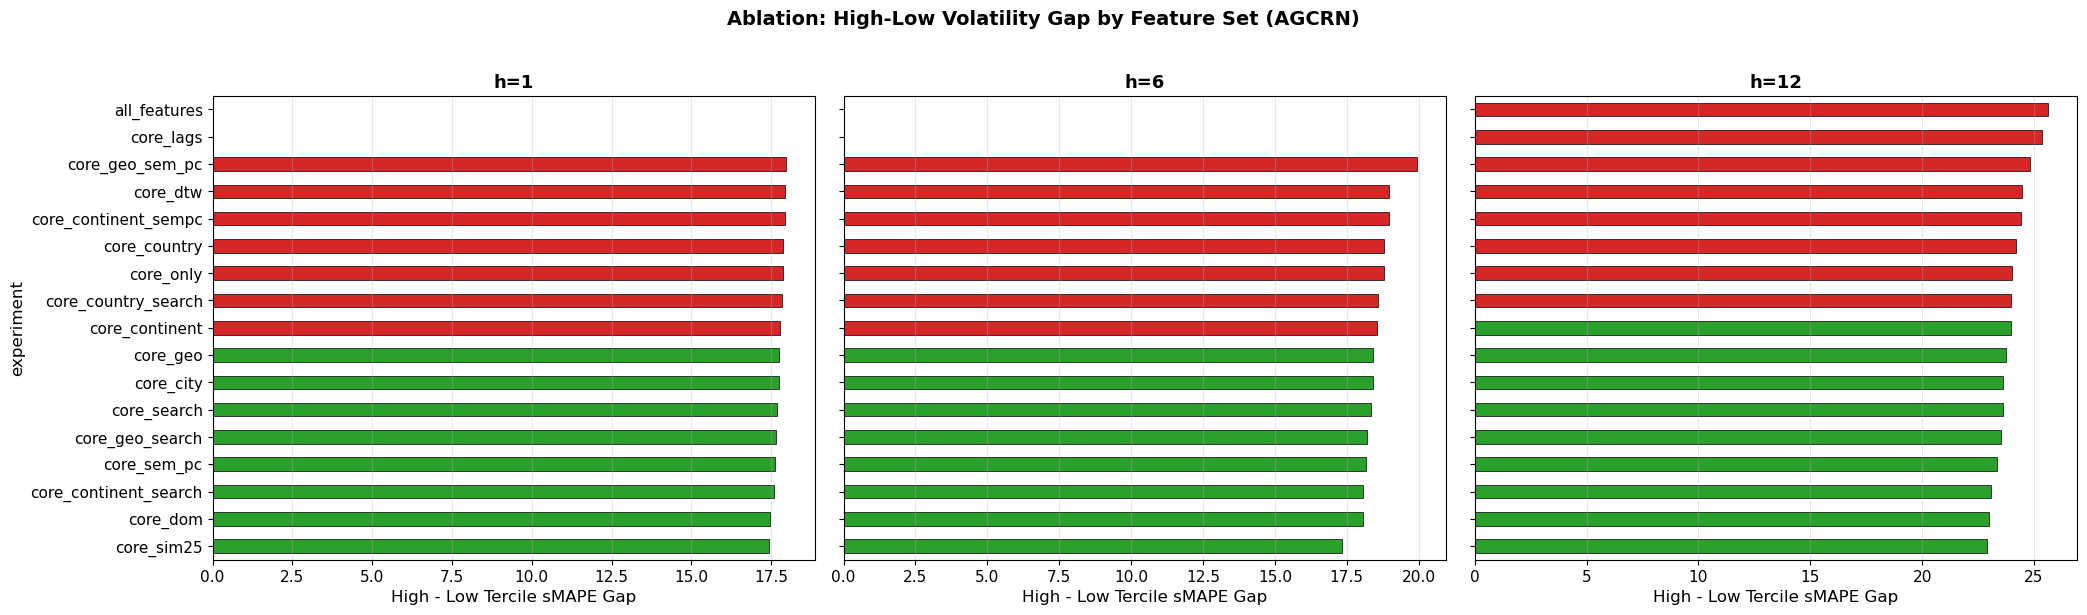

Saved: ablation_tercile_gap.pdf


In [ ]:
# =============================================================================
# VIZ 4: Ablation — tercile gap reduction by feature group (one model)
# =============================================================================
# Pick the model with most ablation coverage and show how each feature group
# changes the High-Low sMAPE gap relative to core_only baseline.
# =============================================================================

if len(abl_df) > 0:
    # Find model with most ablation experiments
    best_model = abl_df.groupby('model')['experiment'].nunique().idxmax()
    print(f"Reference model for ablation viz: {best_model}")

    fig, axes = plt.subplots(1, len(horizons), figsize=(7 * len(horizons), 6), sharey=True)
    if len(horizons) == 1:
        axes = [axes]

    for i, h in enumerate(horizons):
        ax = axes[i]
        sub = abl_df[(abl_df['model'] == best_model) & (abl_df['horizon'] == h)]
        if len(sub) == 0:
            ax.set_title(f'h={h} (no data)')
            continue

        pivot = sub.pivot_table(index='experiment', columns='segment',
                                values='sMAPE', aggfunc='mean')
        if not {'Low', 'High'}.issubset(pivot.columns):
            continue
        pivot['gap'] = pivot['High'] - pivot['Low']
        pivot = pivot.sort_values('gap')

        colors = ['#2ca02c' if g <= pivot['gap'].median() else '#d62728'
                  for g in pivot['gap']]
        pivot['gap'].plot(kind='barh', ax=ax, color=colors,
                          edgecolor='black', linewidth=0.5)
        ax.set_xlabel('High - Low Tercile sMAPE Gap')
        ax.set_title(f'h={h}', fontweight='bold')
        ax.grid(axis='x', alpha=0.3)

    plt.suptitle(f'Ablation: High-Low Volatility Gap by Feature Set ({best_model})',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('ablation_tercile_gap.pdf', bbox_inches='tight', dpi=150)
    plt.show()
    print("Saved: ablation_tercile_gap.pdf")
else:
    print("No ablation data available for this visualization.")

In [ ]:
# =============================================================================
# SUMMARY: Key findings
# =============================================================================

print("=" * 70)
print("SUMMARY: Competitive Frontier Analysis")
print("=" * 70)

exp1_terc = main_df[main_df['seg_type'] == 'tercile']
exp1_quad = main_df[main_df['seg_type'] == 'quadrant']

print("\n1. VOLATILITY TERCILE ANALYSIS")
print("-" * 40)
for h in sorted(exp1_terc['horizon'].unique()):
    sub = exp1_terc[exp1_terc['horizon'] == h]
    avg = sub.groupby('segment')['sMAPE'].mean()
    if 'Low' in avg.index and 'High' in avg.index:
        ratio = avg['High'] / avg['Low']
        print(f"  h={h}: Low={avg['Low']:.1f}%, Med={avg.get('Medium', 0):.1f}%, "
              f"High={avg['High']:.1f}% (High/Low ratio: {ratio:.2f}x)")

print("\n2. COMPETITIVE FRONTIER QUADRANT ANALYSIS")
print("-" * 40)
for h in sorted(exp1_quad['horizon'].unique()):
    sub = exp1_quad[exp1_quad['horizon'] == h]
    avg = sub.groupby('segment')['sMAPE'].mean()
    lo = avg.get('Low CPC / Low Vol', np.nan)
    hi = avg.get('High CPC / High Vol', np.nan)
    if not np.isnan(lo) and not np.isnan(hi):
        print(f"  h={h}: LoLo={lo:.1f}%, HiHi={hi:.1f}% (ratio: {hi/lo:.2f}x)")

print("\n3. BEST MODELS PER SEGMENT (overall best on sMAPE)")
print("-" * 40)
main_overall = main_df[main_df['seg_type'] == 'overall']
for h in sorted(main_overall['horizon'].unique()):
    sub = main_overall[main_overall['horizon'] == h]
    best = sub.loc[sub['sMAPE'].idxmin()]
    print(f"  h={h} overall best: {best['model']} (sMAPE={best['sMAPE']:.1f}%)")

# Best per quadrant
for h in sorted(exp1_quad['horizon'].unique()):
    for q in quadrant_order:
        sub = exp1_quad[(exp1_quad['horizon'] == h) & (exp1_quad['segment'] == q)]
        if len(sub):
            best = sub.loc[sub['sMAPE'].idxmin()]
            print(f"  h={h} | {q:>25s} -> {best['model']:>15s} ({best['sMAPE']:.1f}%)")

print(f"\nTotal results: {len(df_results)} rows")
print(f"Output files: competitive_frontier_results.csv, *.pdf")

SUMMARY: Competitive Frontier Analysis

1. VOLATILITY TERCILE ANALYSIS
----------------------------------------
  h=1: Low=21.6%, Med=28.7%, High=38.5% (High/Low ratio: 1.78x)
  h=6: Low=26.5%, Med=33.3%, High=44.9% (High/Low ratio: 1.69x)
  h=12: Low=33.0%, Med=40.9%, High=56.1% (High/Low ratio: 1.70x)

2. COMPETITIVE FRONTIER QUADRANT ANALYSIS
----------------------------------------
  h=1: LoLo=23.9%, HiHi=36.3% (ratio: 1.52x)
  h=6: LoLo=27.5%, HiHi=43.5% (ratio: 1.58x)
  h=12: LoLo=33.2%, HiHi=56.0% (ratio: 1.69x)

3. BEST MODELS PER SEGMENT (overall best on sMAPE)
----------------------------------------
  h=1 overall best: DCRNN (sMAPE=26.7%)
  h=6 overall best: GraphWaveNet (sMAPE=30.8%)
  h=12 overall best: AGCRN (sMAPE=38.9%)
  h=1 |         Low CPC / Low Vol ->           DCRNN (20.1%)
  h=1 |        Low CPC / High Vol ->           DCRNN (32.2%)
  h=1 |        High CPC / Low Vol ->       GConvLSTM (20.5%)
  h=1 |       High CPC / High Vol ->           DCRNN (34.1%)
  h=6 |   

# Benchmark Integration

Merge per-keyword benchmark results (ML, NN, SARIMAX) into the same segment-level
format used by the GNN tensor analysis, then produce unified tables and plots.

In [ ]:
# =============================================================================
# Load benchmark CSVs and convert to unified segment-level metrics
# =============================================================================
# Benchmark CSVs have per-keyword rows with: keyword, rmse, smape, horizon,
# model_id, exog_mode.  We aggregate these into the same segment-level format
# as df_results (from GNN tensors) so everything can be compared side-by-side.
# =============================================================================

ML_METRICS_PATH = "../3_Benchmarks/results/all_models_per_keyword_metrics.csv"
SARIMAX_METRICS_PATH = "../3_Benchmarks/results/sarimax_per_keyword_metrics_full.csv"

# --- Load ---
dfs = []
for path, label in [(ML_METRICS_PATH, 'ML/NN'), (SARIMAX_METRICS_PATH, 'SARIMAX')]:
    try:
        tmp = pd.read_csv(path)
        dfs.append(tmp)
        print(f"Loaded {label}: {len(tmp)} rows, cols={list(tmp.columns)}")
    except FileNotFoundError:
        print(f"WARNING: {path} not found, skipping.")

df_benchmarks = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
print(f"\nCombined benchmarks: {len(df_benchmarks)} rows")
print(f"Models:    {sorted(df_benchmarks['model_id'].unique())}")
print(f"Horizons:  {sorted(df_benchmarks['horizon'].unique())}")
print(f"Exog modes:{sorted(df_benchmarks['exog_mode'].unique())}")


Loaded ML/NN: 114039 rows, cols=['keyword', 'rmse', 'smape', 'n_points', 'horizon', 'model_id', 'exog_mode']
Loaded SARIMAX: 16299 rows, cols=['keyword', 'exog_mode', 'horizon', 'rmse', 'smape', 'n_points', 'model_id']

Combined benchmarks: 130338 rows
Models:    ['ml | LGBM', 'ml | RF', 'ml | XGB', 'nn | GRU', 'nn | LSTM', 'nn | MLP', 'stats | SARIMAX_kw']
Horizons:  [np.int64(1), np.int64(6), np.int64(12)]
Exog modes:['cpc_only', 'exog_all', 'exog_small']


In [ ]:
# =============================================================================
# Convert per-keyword benchmarks to segment-level metrics (same schema as df_results)
# =============================================================================
# For each (model_id, horizon, exog_mode), aggregate smape/rmse per segment.
# We keep exog_mode as the 'experiment' column to allow filtering later.
# =============================================================================

if not df_benchmarks.empty:
    # Merge benchmarks with keyword segments
    stats_sub = keyword_stats.reset_index()[['keyword', 'vol_tercile', 'quadrant', 'node_idx']]
    df_bm = df_benchmarks.merge(stats_sub, on='keyword', how='inner')
    print(f"After merge with keyword_stats: {len(df_bm)} rows "
          f"({df_bm['keyword'].nunique()} keywords matched)")

    bench_rows = []
    for (model_id, horizon, exog_mode), grp in df_bm.groupby(
            ['model_id', 'horizon', 'exog_mode']):

        row_base = dict(
            exp_group='benchmarks',
            experiment=exog_mode,
            model=model_id,
            horizon=int(horizon),
        )

        # Overall
        bench_rows.append({
            **row_base, 'seg_type': 'overall', 'segment': 'All',
            'RMSE': grp['rmse'].mean(),
            'MAE': np.nan,   # benchmarks don't store MAE per keyword
            'sMAPE': grp['smape'].mean(),
            'n_keywords': grp['keyword'].nunique(),
        })

        # Tercile
        for terc in ['Low', 'Medium', 'High']:
            sub = grp[grp['vol_tercile'] == terc]
            if len(sub):
                bench_rows.append({
                    **row_base, 'seg_type': 'tercile', 'segment': terc,
                    'RMSE': sub['rmse'].mean(),
                    'MAE': np.nan,
                    'sMAPE': sub['smape'].mean(),
                    'n_keywords': sub['keyword'].nunique(),
                })

        # Quadrant
        for quad in quadrant_order:
            sub = grp[grp['quadrant'] == quad]
            if len(sub):
                bench_rows.append({
                    **row_base, 'seg_type': 'quadrant', 'segment': quad,
                    'RMSE': sub['rmse'].mean(),
                    'MAE': np.nan,
                    'sMAPE': sub['smape'].mean(),
                    'n_keywords': sub['keyword'].nunique(),
                })

    df_bench_seg = pd.DataFrame(bench_rows)
    print(f"\nBenchmark segment rows: {len(df_bench_seg)}")
    print(f"Models: {sorted(df_bench_seg['model'].unique())}")

    # --- Unified DataFrame: GNN tensors + benchmarks ---
    df_all = pd.concat([df_results, df_bench_seg], ignore_index=True)
    print(f"\nUnified df_all: {len(df_all)} rows")
    print(f"  GNN tensor rows:  {len(df_results)}")
    print(f"  Benchmark rows:   {len(df_bench_seg)}")
    print(f"  All models:       {sorted(df_all['model'].unique())}")
else:
    df_bench_seg = pd.DataFrame()
    df_all = df_results.copy()
    print("No benchmarks loaded; df_all = df_results only.")

# Save unified results
df_all.to_csv('competitive_frontier_results_unified.csv', index=False)
print("Saved: competitive_frontier_results_unified.csv")

After merge with keyword_stats: 130338 rows (1811 keywords matched)

Benchmark segment rows: 504
Models: ['ml | LGBM', 'ml | RF', 'ml | XGB', 'nn | GRU', 'nn | LSTM', 'nn | MLP', 'stats | SARIMAX_kw']

Unified df_all: 2384 rows
  GNN tensor rows:  1880
  Benchmark rows:   504
  All models:       ['A3TGCN', 'AGCRN', 'DCRNN', 'GConvLSTM', 'GraphWaveNet', 'MTGNN', 'STConv', 'STGCN', 'ml | LGBM', 'ml | RF', 'ml | XGB', 'nn | GRU', 'nn | LSTM', 'nn | MLP', 'stats | SARIMAX_kw']
Saved: competitive_frontier_results_unified.csv


In [ ]:
# =============================================================================
# Unified TABLE: GNN (exp1) + Benchmarks (cpc_only) — Tercile breakdown
# =============================================================================
# Compare the best exog_mode for benchmarks (cpc_only) against the main GNN
# experiment.  Use 'cpc_only' as the fair comparison since GNNs also get CPC
# as the primary signal.
# =============================================================================

# --- Select the comparison slices ---
# GNN models: exp1 (or exp2 fallback) — already in main_df
gnn_terc  = main_df[main_df['seg_type'] == 'tercile'].copy()
gnn_terc['source'] = 'GNN'

gnn_overall = main_df[main_df['seg_type'] == 'overall'].copy()
gnn_overall['source'] = 'GNN'

# Benchmark models: cpc_only exog mode for fair comparison
if len(df_bench_seg):
    bench_terc = df_bench_seg[
        (df_bench_seg['seg_type'] == 'tercile') &
        (df_bench_seg['experiment'] == 'cpc_only')
    ].copy()
    bench_terc['source'] = 'Benchmark'

    bench_overall = df_bench_seg[
        (df_bench_seg['seg_type'] == 'overall') &
        (df_bench_seg['experiment'] == 'cpc_only')
    ].copy()
    bench_overall['source'] = 'Benchmark'

    cmp_terc = pd.concat([gnn_terc, bench_terc], ignore_index=True)
    cmp_overall = pd.concat([gnn_overall, bench_overall], ignore_index=True)
else:
    cmp_terc = gnn_terc
    cmp_overall = gnn_overall

# --- Print unified tercile table ---
print("=" * 80)
print("UNIFIED TABLE: Tercile Breakdown — GNN vs Benchmarks (cpc_only)")
print("=" * 80)

for h in sorted(cmp_terc['horizon'].unique()):
    print(f"\n{'─'*80}")
    print(f"  Horizon h={h}")
    print(f"{'─'*80}")
    sub_t = cmp_terc[cmp_terc['horizon'] == h]
    sub_o = cmp_overall[cmp_overall['horizon'] == h]

    pivot = sub_t.pivot_table(
        index='model', columns='segment', values='sMAPE', aggfunc='mean'
    )
    # Reorder columns safely (handle missing terciles)
    cols = [c for c in ['Low', 'Medium', 'High'] if c in pivot.columns]
    pivot = pivot[cols]

    ov = sub_o.set_index('model')['sMAPE']
    pivot['Overall'] = ov
    if 'Low' in pivot.columns and 'High' in pivot.columns:
        pivot['High/Low'] = (pivot['High'] / pivot['Low']).round(2)

    # Sort by Overall sMAPE
    pivot = pivot.sort_values('Overall', na_position='last')
    print(pivot.round(2).to_string())

UNIFIED TABLE: Tercile Breakdown — GNN vs Benchmarks (cpc_only)

────────────────────────────────────────────────────────────────────────────────
  Horizon h=1
────────────────────────────────────────────────────────────────────────────────
segment               Low  Medium   High  Overall  High/Low
model                                                      
DCRNN               18.46   26.15  35.54    26.72      1.92
GraphWaveNet        18.98   26.80  36.60    27.46      1.93
GConvLSTM           19.31   26.70  36.74    27.58      1.90
STGCN               19.83   27.51  37.52    28.29      1.89
AGCRN               20.06   27.69  37.51    28.42      1.87
STConv              22.49   29.28  39.21    30.33      1.74
nn | MLP            21.13   31.70  42.63    31.83      2.02
nn | LSTM           21.36   32.06  43.03    32.16      2.01
ml | XGB            21.51   31.99  43.02    32.18      2.00
ml | LGBM           21.53   31.98  43.02    32.18      2.00
nn | GRU            21.56   32.20  43.1

In [ ]:
# =============================================================================
# Unified TABLE: GNN (exp1) + Benchmarks (cpc_only) — Quadrant breakdown
# =============================================================================

# --- Quadrant comparison ---
gnn_quad = main_df[main_df['seg_type'] == 'quadrant'].copy()
gnn_quad['source'] = 'GNN'

if len(df_bench_seg):
    bench_quad = df_bench_seg[
        (df_bench_seg['seg_type'] == 'quadrant') &
        (df_bench_seg['experiment'] == 'cpc_only')
    ].copy()
    bench_quad['source'] = 'Benchmark'
    cmp_quad = pd.concat([gnn_quad, bench_quad], ignore_index=True)
else:
    cmp_quad = gnn_quad

print("=" * 90)
print("UNIFIED TABLE: Quadrant Breakdown — GNN vs Benchmarks (cpc_only)")
print("=" * 90)

for h in sorted(cmp_quad['horizon'].unique()):
    print(f"\n{'─'*90}")
    print(f"  Horizon h={h}")
    print(f"{'─'*90}")
    sub = cmp_quad[cmp_quad['horizon'] == h]

    pivot = sub.pivot_table(
        index='model', columns='segment', values='sMAPE', aggfunc='mean'
    )
    # Reorder safely
    cols = [c for c in quadrant_order if c in pivot.columns]
    pivot = pivot[cols]

    if 'High CPC / High Vol' in pivot.columns and 'Low CPC / Low Vol' in pivot.columns:
        pivot['HiHi/LoLo'] = (
            pivot['High CPC / High Vol'] / pivot['Low CPC / Low Vol']
        ).round(2)

    pivot = pivot.sort_values(cols[0] if cols else pivot.columns[0], na_position='last')
    print(pivot.round(2).to_string())

UNIFIED TABLE: Quadrant Breakdown — GNN vs Benchmarks (cpc_only)

──────────────────────────────────────────────────────────────────────────────────────────
  Horizon h=1
──────────────────────────────────────────────────────────────────────────────────────────
segment             Low CPC / Low Vol  Low CPC / High Vol  High CPC / Low Vol  High CPC / High Vol  HiHi/LoLo
model                                                                                                        
DCRNN                           20.11               32.23               20.53                34.15       1.70
GraphWaveNet                    20.90               33.15               21.05                34.89       1.67
GConvLSTM                       21.90               33.55               20.50                34.65       1.58
STGCN                           22.40               34.40               21.34                35.21       1.57
AGCRN                           23.55               34.61               20.64 

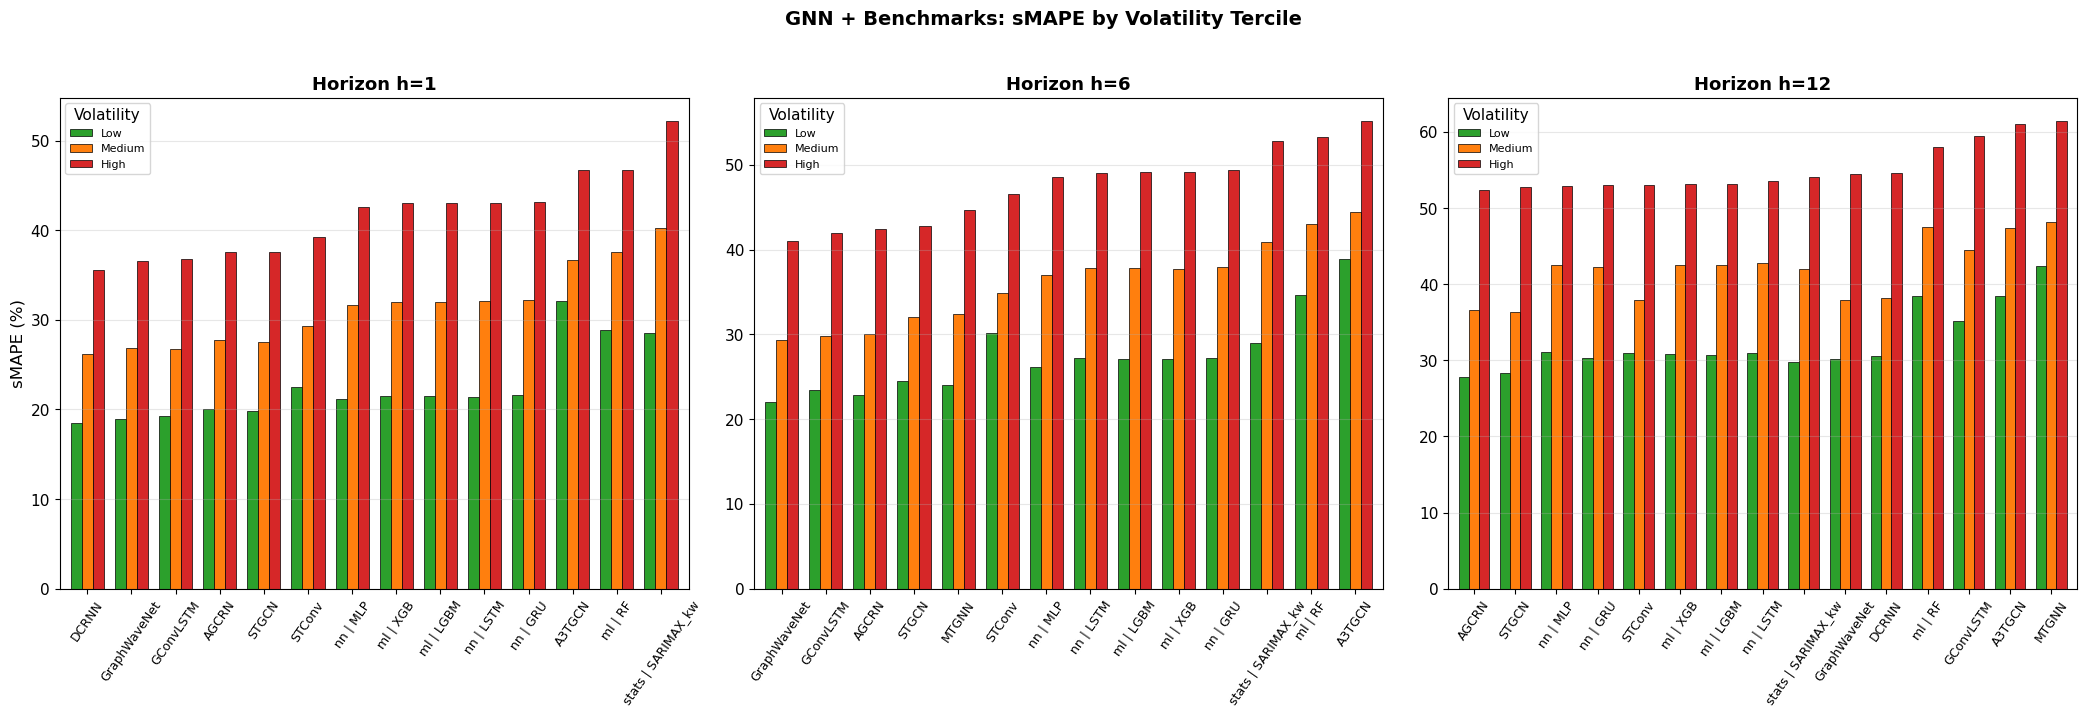

Saved: unified_tercile_bars.pdf


In [ ]:
# =============================================================================
# VIZ: Unified bar charts — GNN + Benchmarks by Tercile (sMAPE)
# =============================================================================

terc_colors = {'Low': '#2ca02c', 'Medium': '#ff7f0e', 'High': '#d62728'}
uni_horizons = sorted(cmp_terc['horizon'].unique())

fig, axes = plt.subplots(1, len(uni_horizons),
                         figsize=(7 * len(uni_horizons), 7), sharey=False)
if len(uni_horizons) == 1:
    axes = [axes]

for i, h in enumerate(uni_horizons):
    ax = axes[i]
    sub = cmp_terc[cmp_terc['horizon'] == h]
    pivot = sub.pivot_table(index='model', columns='segment',
                            values='sMAPE', aggfunc='mean')
    cols = [c for c in ['Low', 'Medium', 'High'] if c in pivot.columns]
    pivot = pivot[cols].sort_values(cols[-1], na_position='last')

    pivot.plot(kind='bar', ax=ax,
               color=[terc_colors[c] for c in cols],
               edgecolor='black', linewidth=0.5, width=0.75)
    ax.set_title(f'Horizon h={h}', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('sMAPE (%)' if i == 0 else '')
    ax.tick_params(axis='x', rotation=55, labelsize=9)
    ax.legend(title='Volatility', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('GNN + Benchmarks: sMAPE by Volatility Tercile',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('unified_tercile_bars.pdf', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: unified_tercile_bars.pdf")

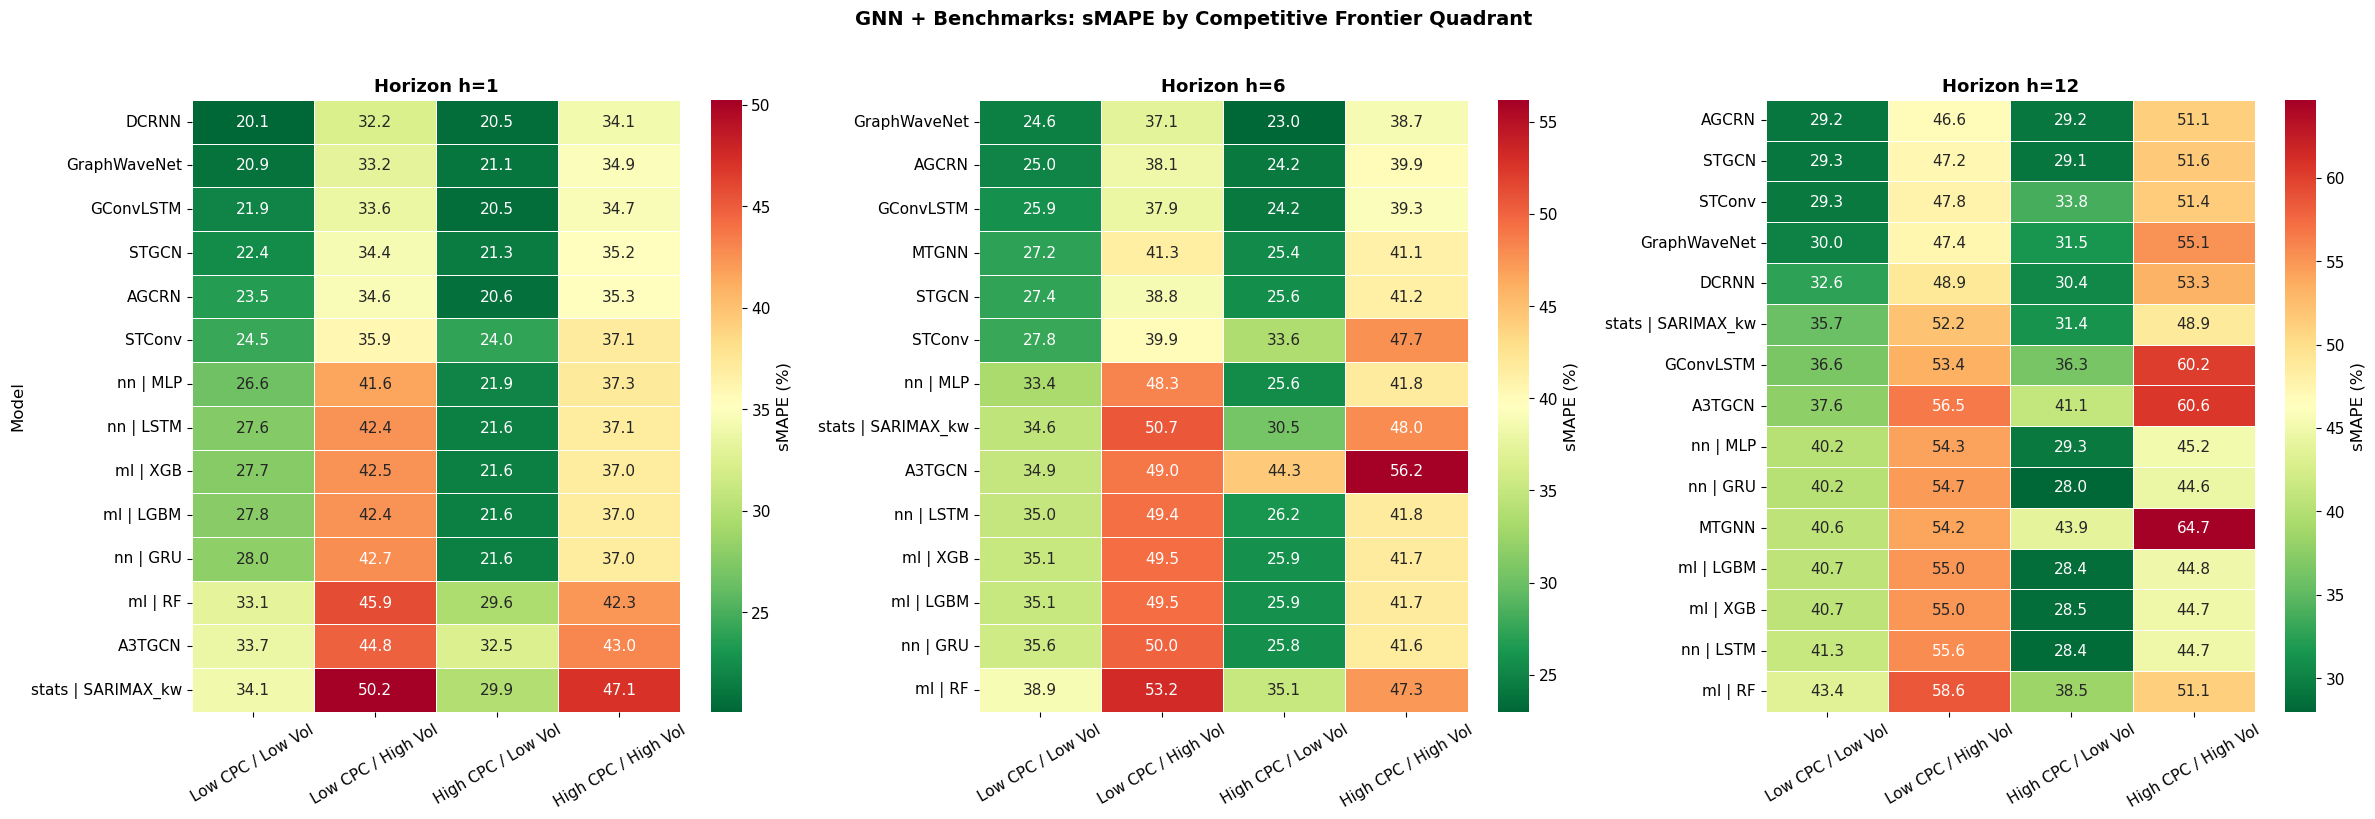

Saved: unified_quadrant_heatmaps.pdf


In [ ]:
# =============================================================================
# VIZ: Unified quadrant heatmaps — GNN + Benchmarks
# =============================================================================

fig, axes = plt.subplots(1, len(uni_horizons),
                         figsize=(8 * len(uni_horizons), max(8, len(cmp_quad['model'].unique()) * 0.45)))
if len(uni_horizons) == 1:
    axes = [axes]

for i, h in enumerate(uni_horizons):
    ax = axes[i]
    sub = cmp_quad[cmp_quad['horizon'] == h]
    pivot = sub.pivot_table(index='model', columns='segment',
                            values='sMAPE', aggfunc='mean')
    cols = [c for c in quadrant_order if c in pivot.columns]
    pivot = pivot[cols].sort_values(cols[0], na_position='last')

    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=ax,
                linewidths=0.5, cbar_kws={'label': 'sMAPE (%)'})
    ax.set_title(f'Horizon h={h}', fontweight='bold')
    ax.set_ylabel('' if i > 0 else 'Model')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('GNN + Benchmarks: sMAPE by Competitive Frontier Quadrant',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('unified_quadrant_heatmaps.pdf', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: unified_quadrant_heatmaps.pdf")

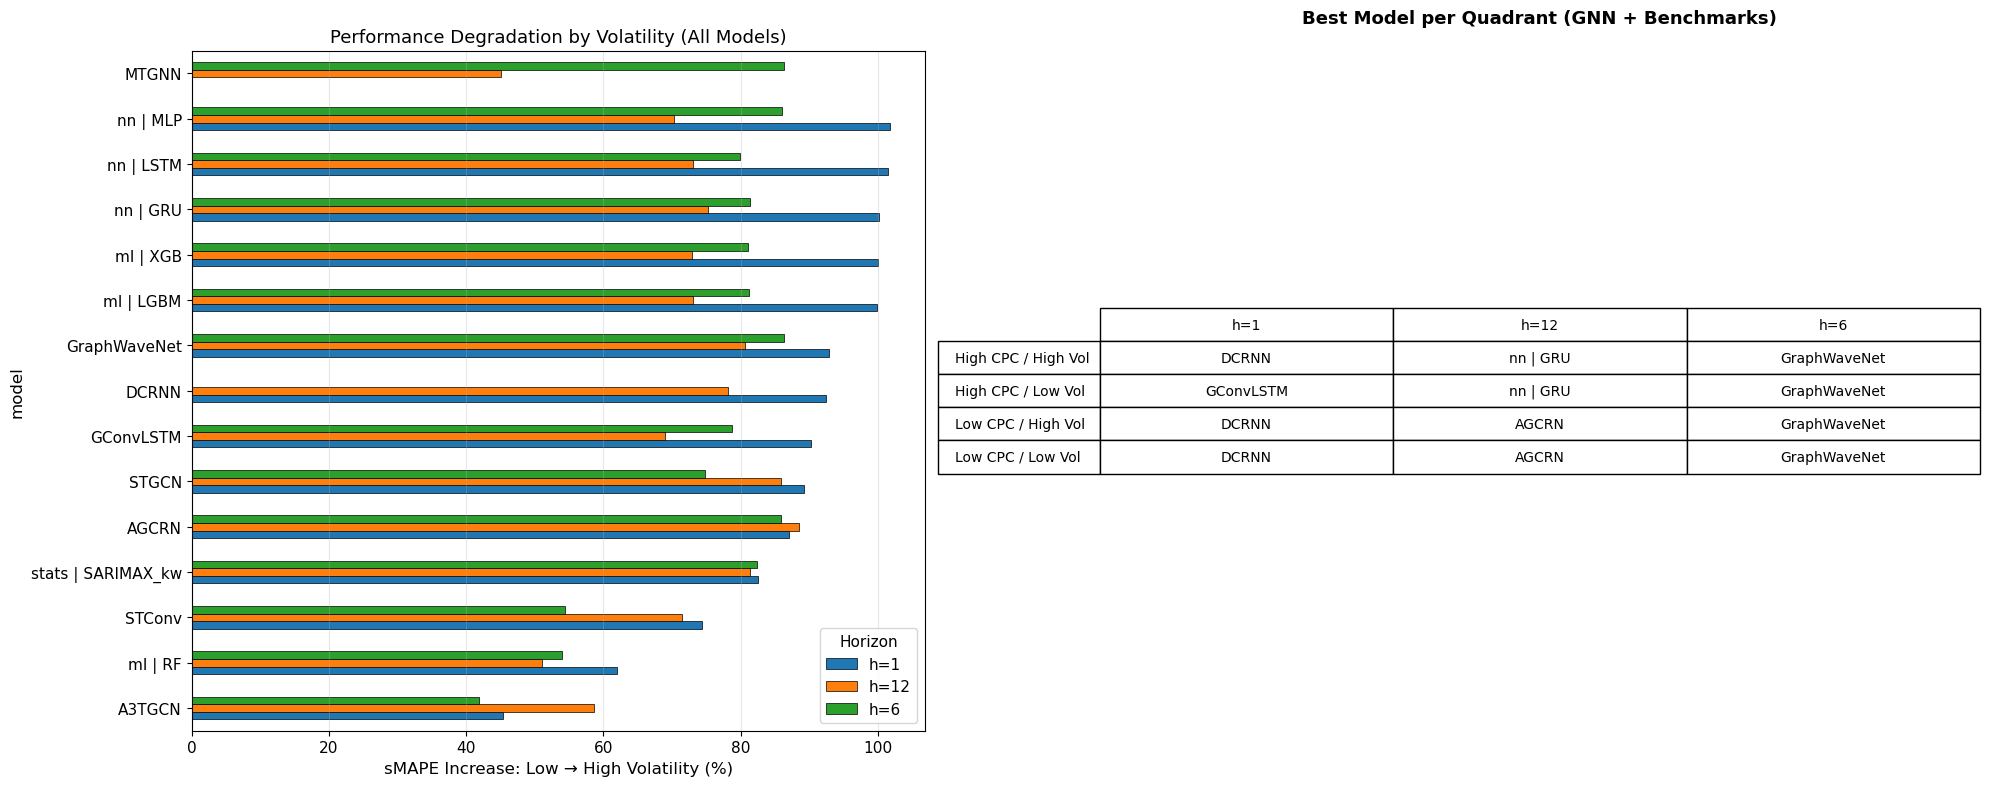

Saved: unified_performance_degradation.pdf


In [ ]:
# =============================================================================
# VIZ: Performance degradation — High vs Low volatility (GNN + Benchmarks)
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# --- Left: sMAPE % increase from Low to High tercile ---
ax = axes[0]
deg_rows = []
for h in uni_horizons:
    for model in sorted(cmp_terc['model'].unique()):
        sub = cmp_terc[(cmp_terc['horizon'] == h) & (cmp_terc['model'] == model)]
        low_v  = sub.loc[sub['segment'] == 'Low', 'sMAPE'].values
        high_v = sub.loc[sub['segment'] == 'High', 'sMAPE'].values
        if len(low_v) and len(high_v):
            pct = 100.0 * (high_v[0] - low_v[0]) / (low_v[0] + 1e-8)
            deg_rows.append({'model': model, 'horizon': f'h={h}', 'pct': pct})

deg_df_uni = pd.DataFrame(deg_rows)
if len(deg_df_uni):
    pivot_deg = deg_df_uni.pivot_table(index='model', columns='horizon', values='pct')
    pivot_deg = pivot_deg.sort_values(pivot_deg.columns[0], na_position='last')
    pivot_deg.plot(kind='barh', ax=ax, edgecolor='black', linewidth=0.5)
    ax.set_xlabel('sMAPE Increase: Low → High Volatility (%)')
    ax.set_title('Performance Degradation by Volatility (All Models)')
    ax.legend(title='Horizon')
    ax.grid(axis='x', alpha=0.3)

# --- Right: Best model per quadrant (all models) ---
ax2 = axes[1]
best_rows = []
for h in uni_horizons:
    for quad in quadrant_order:
        sub = cmp_quad[(cmp_quad['horizon'] == h) & (cmp_quad['segment'] == quad)]
        if len(sub):
            best = sub.loc[sub['sMAPE'].idxmin()]
            best_rows.append({
                'horizon': f'h={h}', 'quadrant': quad,
                'best_model': best['model'],
                'sMAPE': f"{best['sMAPE']:.1f}",
            })

best_df_uni = pd.DataFrame(best_rows)
if len(best_df_uni):
    pivot_best = best_df_uni.pivot_table(
        index='quadrant', columns='horizon',
        values='best_model', aggfunc='first'
    )
    ax2.axis('off')
    table = ax2.table(cellText=pivot_best.values,
                      rowLabels=pivot_best.index, colLabels=pivot_best.columns,
                      cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.8)
    ax2.set_title('Best Model per Quadrant (GNN + Benchmarks)',
                  fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('unified_performance_degradation.pdf', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: unified_performance_degradation.pdf")

In [ ]:
# =============================================================================
# Benchmark exog_mode comparison: does exog setting matter per segment?
# =============================================================================
# Show that for benchmarks, the exog_mode that helps most may differ by
# volatility segment.
# =============================================================================

if len(df_bench_seg):
    bench_terc_all = df_bench_seg[df_bench_seg['seg_type'] == 'tercile'].copy()

    print("=" * 80)
    print("BENCHMARK EXOG MODE COMPARISON BY TERCILE")
    print("=" * 80)

    for h in sorted(bench_terc_all['horizon'].unique()):
        print(f"\n{'─'*80}")
        print(f"  Horizon h={h}")
        print(f"{'─'*80}")
        sub = bench_terc_all[bench_terc_all['horizon'] == h]

        pivot = sub.pivot_table(
            index=['model', 'experiment'],
            columns='segment',
            values='sMAPE', aggfunc='mean'
        )
        cols = [c for c in ['Low', 'Medium', 'High'] if c in pivot.columns]
        pivot = pivot[cols]
        if 'Low' in cols and 'High' in cols:
            pivot['High/Low'] = (pivot['High'] / pivot['Low']).round(2)
        pivot = pivot.sort_values(cols[0], na_position='last')
        print(pivot.round(2).to_string())
else:
    print("No benchmark data available.")

BENCHMARK EXOG MODE COMPARISON BY TERCILE

────────────────────────────────────────────────────────────────────────────────
  Horizon h=1
────────────────────────────────────────────────────────────────────────────────
segment                          Low  Medium   High  High/Low
model              experiment                                
nn | MLP           exog_small  19.97   30.17  41.10      2.06
ml | LGBM          exog_small  20.15   30.54  41.33      2.05
ml | XGB           exog_small  20.19   30.59  41.34      2.05
                   exog_all    20.48   31.30  42.31      2.07
nn | LSTM          exog_small  20.49   30.58  40.99      2.00
nn | GRU           exog_small  20.59   30.95  41.43      2.01
nn | LSTM          exog_all    20.64   31.27  42.09      2.04
ml | LGBM          exog_all    20.81   31.74  42.66      2.05
ml | RF            exog_all    20.82   31.40  42.35      2.03
nn | MLP           cpc_only    21.13   31.70  42.63      2.02
ml | RF            exog_small  21.16 

In [ ]:
# =============================================================================
# UNIFIED SUMMARY: All models, all experiments — coverage & best per segment
# =============================================================================
# Handles incomplete results: not every experiment has every model/horizon.
# =============================================================================

print("=" * 80)
print("UNIFIED SUMMARY — GNN + Benchmarks")
print("=" * 80)

# --- Coverage report ---
print("\n1. MODEL COVERAGE")
print("-" * 50)
coverage = df_all.groupby(['exp_group', 'experiment', 'model']).agg(
    horizons=('horizon', lambda x: sorted(x.unique().tolist())),
    n_rows=('sMAPE', 'count'),
).reset_index()
for (eg, exp), grp in coverage.groupby(['exp_group', 'experiment']):
    n_models = grp['model'].nunique()
    print(f"\n  [{eg} / {exp}] — {n_models} models")
    for _, row in grp.iterrows():
        print(f"    {row['model']:>25s}  horizons={row['horizons']}")

# --- Overall best per horizon (all sources, cpc_only for benchmarks) ---
print("\n\n2. BEST MODEL PER HORIZON (overall sMAPE)")
print("-" * 50)
# Use cpc_only for benchmarks, all GNN experiments
fair = df_all[
    ((df_all['exp_group'] != 'benchmarks') |
     (df_all['experiment'] == 'cpc_only')) &
    (df_all['seg_type'] == 'overall')
]
for h in sorted(fair['horizon'].unique()):
    sub = fair[fair['horizon'] == h]
    if len(sub):
        best = sub.loc[sub['sMAPE'].idxmin()]
        print(f"  h={h}: {best['model']:>25s} ({best['exp_group']}/{best['experiment']}) "
              f"sMAPE={best['sMAPE']:.1f}%")

# --- Best per tercile ---
print("\n\n3. BEST MODEL PER VOLATILITY TERCILE")
print("-" * 50)
fair_terc = df_all[
    ((df_all['exp_group'] != 'benchmarks') |
     (df_all['experiment'] == 'cpc_only')) &
    (df_all['seg_type'] == 'tercile')
]
for h in sorted(fair_terc['horizon'].unique()):
    print(f"\n  Horizon h={h}")
    for terc in ['Low', 'Medium', 'High']:
        sub = fair_terc[(fair_terc['horizon'] == h) & (fair_terc['segment'] == terc)]
        if len(sub):
            best = sub.loc[sub['sMAPE'].idxmin()]
            print(f"    {terc:>8s} → {best['model']:>25s} "
                  f"({best['exp_group']}) sMAPE={best['sMAPE']:.1f}%")

# --- Best per quadrant ---
print("\n\n4. BEST MODEL PER COMPETITIVE FRONTIER QUADRANT")
print("-" * 50)
fair_quad = df_all[
    ((df_all['exp_group'] != 'benchmarks') |
     (df_all['experiment'] == 'cpc_only')) &
    (df_all['seg_type'] == 'quadrant')
]
for h in sorted(fair_quad['horizon'].unique()):
    print(f"\n  Horizon h={h}")
    for quad in quadrant_order:
        sub = fair_quad[(fair_quad['horizon'] == h) & (fair_quad['segment'] == quad)]
        if len(sub):
            best = sub.loc[sub['sMAPE'].idxmin()]
            print(f"    {quad:>25s} → {best['model']:>25s} "
                  f"({best['exp_group']}) sMAPE={best['sMAPE']:.1f}%")

print(f"\n\nTotal unified rows: {len(df_all)}")
print(f"Unique models: {sorted(df_all['model'].unique())}")
print(f"Output: competitive_frontier_results_unified.csv")

UNIFIED SUMMARY — GNN + Benchmarks

1. MODEL COVERAGE
--------------------------------------------------

  [ablation2_tensors / core_geo_search] — 4 models
                        AGCRN  horizons=[1, 6, 12]
                        DCRNN  horizons=[1, 6, 12]
                    GConvLSTM  horizons=[1, 6, 12]
                 GraphWaveNet  horizons=[1, 6, 12]

  [ablation2_tensors / core_geo_sem_pc] — 4 models
                        AGCRN  horizons=[1, 6, 12]
                        DCRNN  horizons=[1, 6, 12]
                    GConvLSTM  horizons=[1, 6, 12]
                 GraphWaveNet  horizons=[1, 6, 12]

  [ablation_tensors / all_features] — 4 models
                        AGCRN  horizons=[1, 6, 12]
                        DCRNN  horizons=[1, 6, 12]
                    GConvLSTM  horizons=[1, 6, 12]
                 GraphWaveNet  horizons=[1, 6, 12]

  [ablation_tensors / core_dom] — 4 models
                        AGCRN  horizons=[1, 6, 12]
                        DCRNN  horiz